Plot the schematic diagram of the 2-D control process (in paper).

In [16]:
import sys
sys.path.insert(1, 'E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts')

import cv2
import matplotlib.pyplot as plt

from utils import *
import camera_settings
import path_settings

In [17]:
exp_name = 'EXP007'
i = 7

data_alias = 'D' + str(0).zfill(2)
method_dir = os.path.join(path_settings.results_dir, exp_name)
data_dir = os.path.join(method_dir, data_alias + '_' + str(i).zfill(4))
print(data_dir)

E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/results\EXP007\D00_0007


In [18]:
path = "E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/data/target_parameters"
target_name = "target_7"
params_save_path = path + '/' + target_name + '.npy'
print(params_save_path)

E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/data/target_parameters/target_7.npy


In [19]:
# path = os.path.join(data_dir, 'cc_specs')
# params_save_path = path + '/' + 'target' + '.npy'
# print(params_save_path)

img_path = os.path.join(data_dir, 'images')
image_save_path = img_path + '/' + '010.png'
print(image_save_path)

E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/results\EXP007\D00_0007\images/010.png


In [20]:
def convert_3d_to_2d(p, camera_extrinsics, fx, fy, cx, cy):
    """
    Convert 3D points to 2D points
    """ 
    p_4d = np.append(p, 1)
    p_cam = camera_extrinsics @ p_4d
    p_x = p_cam[0] * fx / (-p_cam[2]) + cx # the f here is already multiplied by scaling factor
    p_y = p_cam[1] * fy / (-p_cam[2]) + cy
    p_2d = np.array([p_x, p_y])
    
    p_2d[0] = round(p_2d[0])
    p_2d[1] = round(480 - p_2d[1])
    
    
    return p_2d

In [21]:
def bezier_curve_2d(P0, P1, P2, num_points=100):
    """
    Compute points on a 2D quadratic Bezier curve
    
    Parameters:
    P0, P1, P2: Control points of the Bezier curve (array-like, 2D coordinates)
    num_points: Number of points to generate on the Bezier curve (default 100)
    
    Returns:
    bezier_points: Numpy array of points on the Bezier curve
    """
    # Define the function to compute a point on the Bezier curve for a given t
    def bezier_curve(t, P0, P1, P2):
        return (1 - t)**2 * P0 + 2 * (1 - t) * t * P1 + t**2 * P2
    
    # Generate t values
    t_values = np.linspace(0, 1, num_points)
    
    # Compute all points on the Bezier curve
    bezier_points = np.array([bezier_curve(t, P0, P1, P2) for t in t_values])
    
    return bezier_points

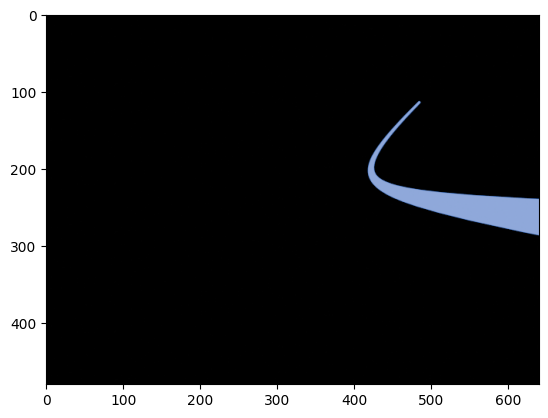

In [22]:
image = cv2.imread(image_save_path)
# Convert color channel: BGR -> RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

[ 0.17940794 -0.13758541  0.96327854]
[0.02094144 0.00117563 0.50466724]
(100, 3)


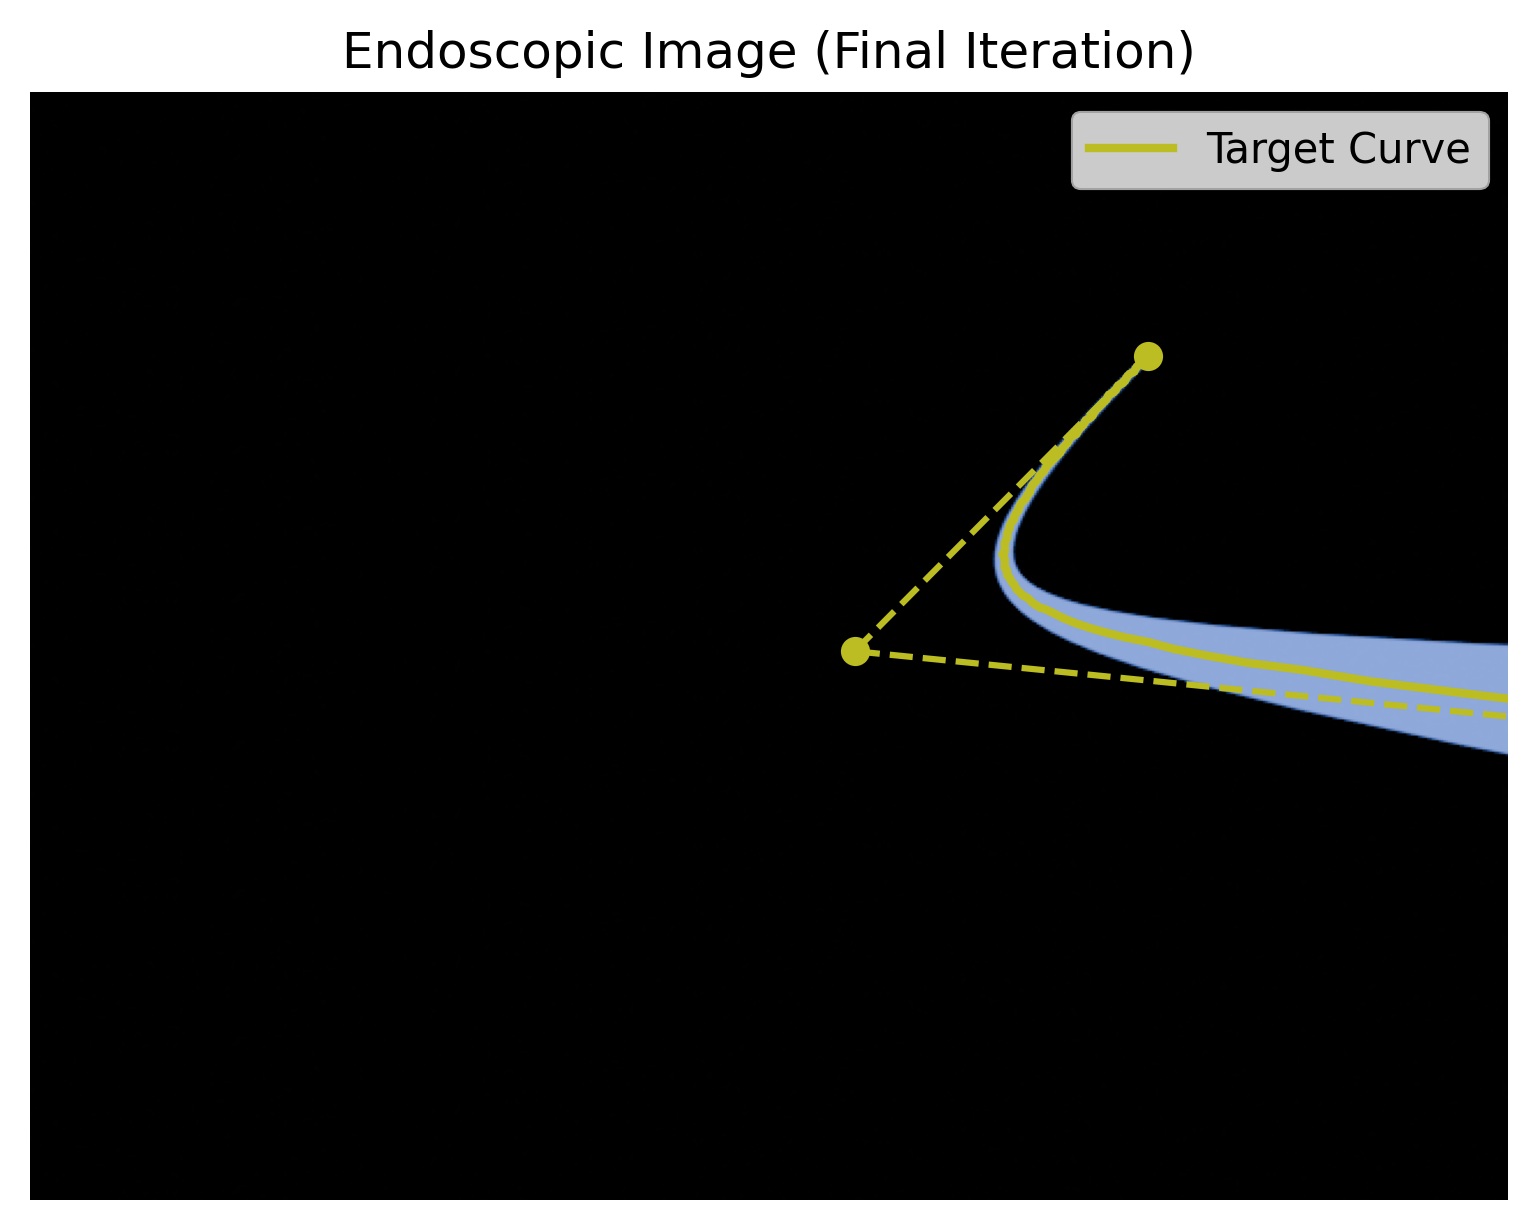

In [23]:
# para_gt_np = np.load(params_save_path)

# p2_3d = para_gt_np[2, :]
# p1_3d = para_gt_np[1, :]
# p0_3d = para_gt_np[0, :]

para_gt = read_gt_params(params_save_path)
p2_3d = para_gt[-3:]
p1_3d = para_gt[:3]
p0_3d = np.array([2e-2, 2e-3, 0.00001])

print(p2_3d)
print(p1_3d)

control_points = np.vstack([p0_3d, p1_3d, p2_3d])

bezier_3d = bezier_curve_3d(control_points)

print(bezier_3d.shape)

bezier_2d = np.zeros((bezier_3d.shape[0], 2))
for i in range(bezier_3d.shape[0]):
    bezier_2d[i] = convert_3d_to_2d(bezier_3d[i], camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
    
p2_2d = convert_3d_to_2d(p2_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
p1_2d = convert_3d_to_2d(p1_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
p0_2d = convert_3d_to_2d(p0_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
    
bezier_points = bezier_2d[1:, :]
# bezier_points = bezier_2d

plt.figure(dpi=300)
plt.imshow(image)

color_target = '#bcbd22'

# Plot the Bezier curve
plt.plot(bezier_points[:, 0], bezier_points[:, 1], color=color_target, linewidth=2, label='Target Curve')

# Plot control points
plt.scatter([p0_2d[0], p1_2d[0], p2_2d[0]], [p0_2d[1], p1_2d[1], p2_2d[1]], color=color_target)
# Connect control points with dashed lines (P0 to P1, P1 to P2)
plt.plot([p0_2d[0], p1_2d[0]], [p0_2d[1], p1_2d[1]], linestyle='--', color=color_target)
plt.plot([p1_2d[0], p2_2d[0]], [p1_2d[1], p2_2d[1]], linestyle='--', color=color_target)

# Set the axis limits to match the image size
plt.xlim(0, 640)  # X axis limit for image width
plt.ylim(480, 0)  # Y axis limit for image height, inverted to match image coordinates

plt.title("Endoscopic Image (Final Iteration)")
plt.axis('off')  
plt.legend()
plt.show()

In [24]:
image_save_path = img_path + '/' + '000.png'

[ 0.17940794 -0.13758541  0.96327854]
[0.02094144 0.00117563 0.50466724]
(100, 3)


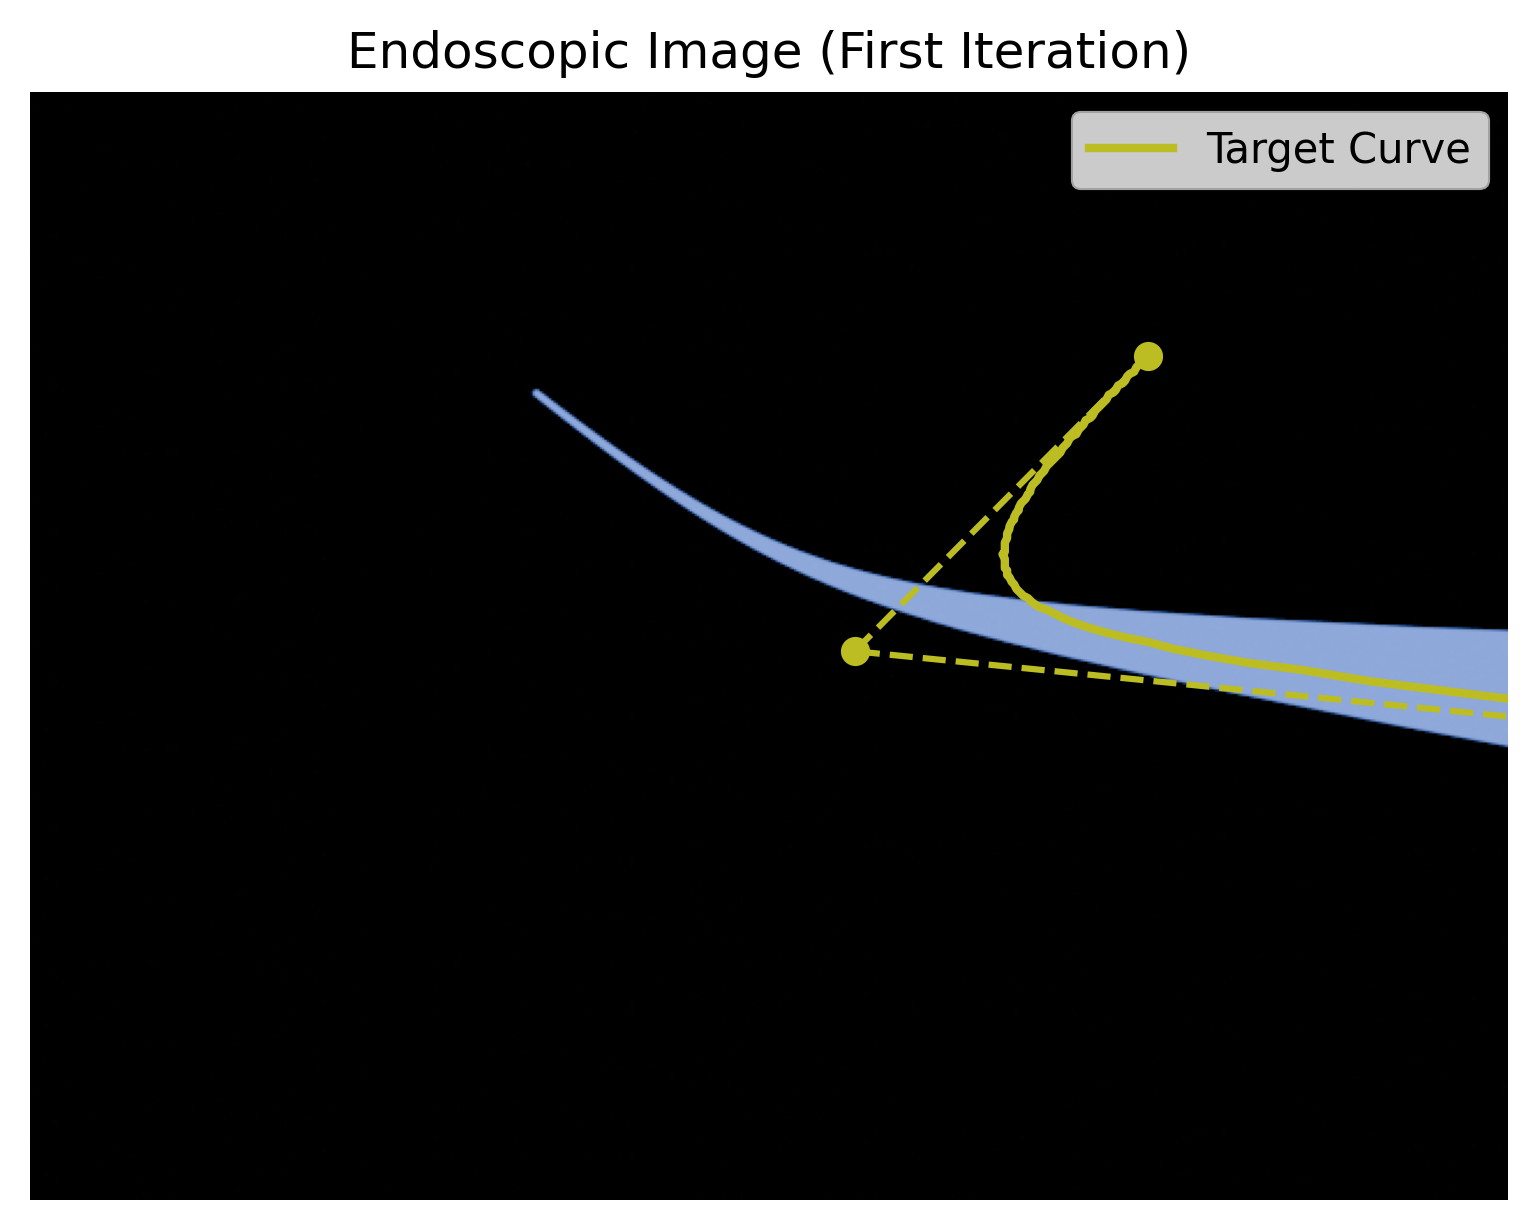

In [25]:
image = cv2.imread(image_save_path)
# Convert color channel: BGR -> RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

para_gt = read_gt_params(params_save_path)
p2_3d = para_gt[-3:]
p1_3d = para_gt[:3]
p0_3d = np.array([2e-2, 2e-3, 0.00001])

print(p2_3d)
print(p1_3d)

control_points = np.vstack([p0_3d, p1_3d, p2_3d])

bezier_3d = bezier_curve_3d(control_points)

print(bezier_3d.shape)

bezier_2d = np.zeros((bezier_3d.shape[0], 2))
for i in range(bezier_3d.shape[0]):
    bezier_2d[i] = convert_3d_to_2d(bezier_3d[i], camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
    
p2_2d = convert_3d_to_2d(p2_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
p1_2d = convert_3d_to_2d(p1_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
p0_2d = convert_3d_to_2d(p0_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
    
bezier_points = bezier_2d[1:, :]
# bezier_points = bezier_2d

plt.figure(dpi=300)
plt.imshow(image)

color_target = '#bcbd22'

# Plot the Bezier curve
plt.plot(bezier_points[:, 0], bezier_points[:, 1], color=color_target, linewidth=2, label='Target Curve')

# Plot control points
plt.scatter([p0_2d[0], p1_2d[0], p2_2d[0]], [p0_2d[1], p1_2d[1], p2_2d[1]], color=color_target)
# Connect control points with dashed lines (P0 to P1, P1 to P2)
plt.plot([p0_2d[0], p1_2d[0]], [p0_2d[1], p1_2d[1]], linestyle='--', color=color_target)
plt.plot([p1_2d[0], p2_2d[0]], [p1_2d[1], p2_2d[1]], linestyle='--', color=color_target)

# Set the axis limits to match the image size
plt.xlim(0, 640)  # X axis limit for image width
plt.ylim(480, 0)  # Y axis limit for image height, inverted to match image coordinates


plt.title("Endoscopic Image (First Iteration)")
plt.axis('off')  
plt.legend()
plt.show()

In [26]:
from PIL import Image, ImageEnhance, ImageFilter

def remove_black_background(image_path, output_path, tolerance=10, blur_radius=1):
    """
    Remove the black background from an image and make it transparent.
    
    :param image_path: Path to the input image
    :param output_path: Path to save the processed image
    :param tolerance: Color tolerance for removing near-black pixels (default=10)
    :param blur_radius: Gaussian blur radius for smoothing edges (default=1)
    """
    # Open the overlay image
    overlay = Image.open(image_path).convert("RGBA")
    pixels = overlay.load()

    # Get image size
    width, height = overlay.size

    def is_blackish(pixel, threshold):
        """ Check if the pixel is close to black based on RGB values """
        return all(c < threshold for c in pixel[:3])  # Ignore alpha channel

    # Process each pixel to remove near-black colors
    for x in range(width):
        for y in range(height):
            r, g, b, a = pixels[x, y]

            if is_blackish((r, g, b), tolerance):
                pixels[x, y] = (0, 0, 0, 0)  # Set to fully transparent

    # Apply slight Gaussian blur to smooth edges
    if blur_radius > 0:
        overlay = overlay.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    # Save the processed image
    overlay.save(output_path)

    # Show the result
    overlay.show()

In [27]:
bg_path = img_path + '/' + '010.png'
overlay_path_1 = img_path + '/' + '000.png'
overlay_path_2 = img_path + '/' + '001.png'
overlay_transparent_path_1 = img_path + '/' + '000_transparent.png'
overlay_transparent_path_2 = img_path + '/' + '001_transparent.png'

remove_black_background(overlay_path_1, overlay_transparent_path_1)
remove_black_background(overlay_path_2, overlay_transparent_path_2)

In [28]:
def overlay_images(background_path, overlay_list, output_path):
    """
    Overlay multiple transparent images onto a background image.
    
    :param background_path: Path to the background image
    :param overlay_list: List of (overlay_path, position, alpha_factor) tuples
    :param output_path: Path to save the final image
    """
    # Open the background image
    background = Image.open(background_path).convert("RGBA")

    # Create an empty transparent layer the same size as the background
    temp_layer = Image.new("RGBA", background.size, (0, 0, 0, 0))

    for overlay_path, position, alpha_factor in overlay_list:
        # Open the overlay image
        overlay = Image.open(overlay_path).convert("RGBA")
        
        # Adjust overlay transparency
        overlay = overlay.copy()
        alpha_channel = overlay.getchannel("A")  # Get alpha channel
        alpha_channel = ImageEnhance.Brightness(alpha_channel).enhance(alpha_factor)  # Adjust transparency
        overlay.putalpha(alpha_channel)  # Apply new alpha channel

        # Paste overlay onto the temp layer at the given position
        temp_layer.paste(overlay, position, overlay)

    # Composite the temp_layer onto the background
    result = Image.alpha_composite(background, temp_layer)

    # Save and show the result
    result.save(output_path)
    result.show()

In [29]:
overlay_transparent_paths = [
    (overlay_transparent_path_1, (0, 0), 0.7),  # Overlay 1 at (50, 50) with 70% opacity
    (overlay_transparent_path_2, (0, 0), 0.9),  # Overlay 2 at (150, 100) with 50% opacity
]

output_path = img_path + '/' + 'output.png'

overlay_images(bg_path, overlay_transparent_paths, output_path)

[ 0.17940794 -0.13758541  0.96327854]
[0.02094144 0.00117563 0.50466724]
(100, 3)


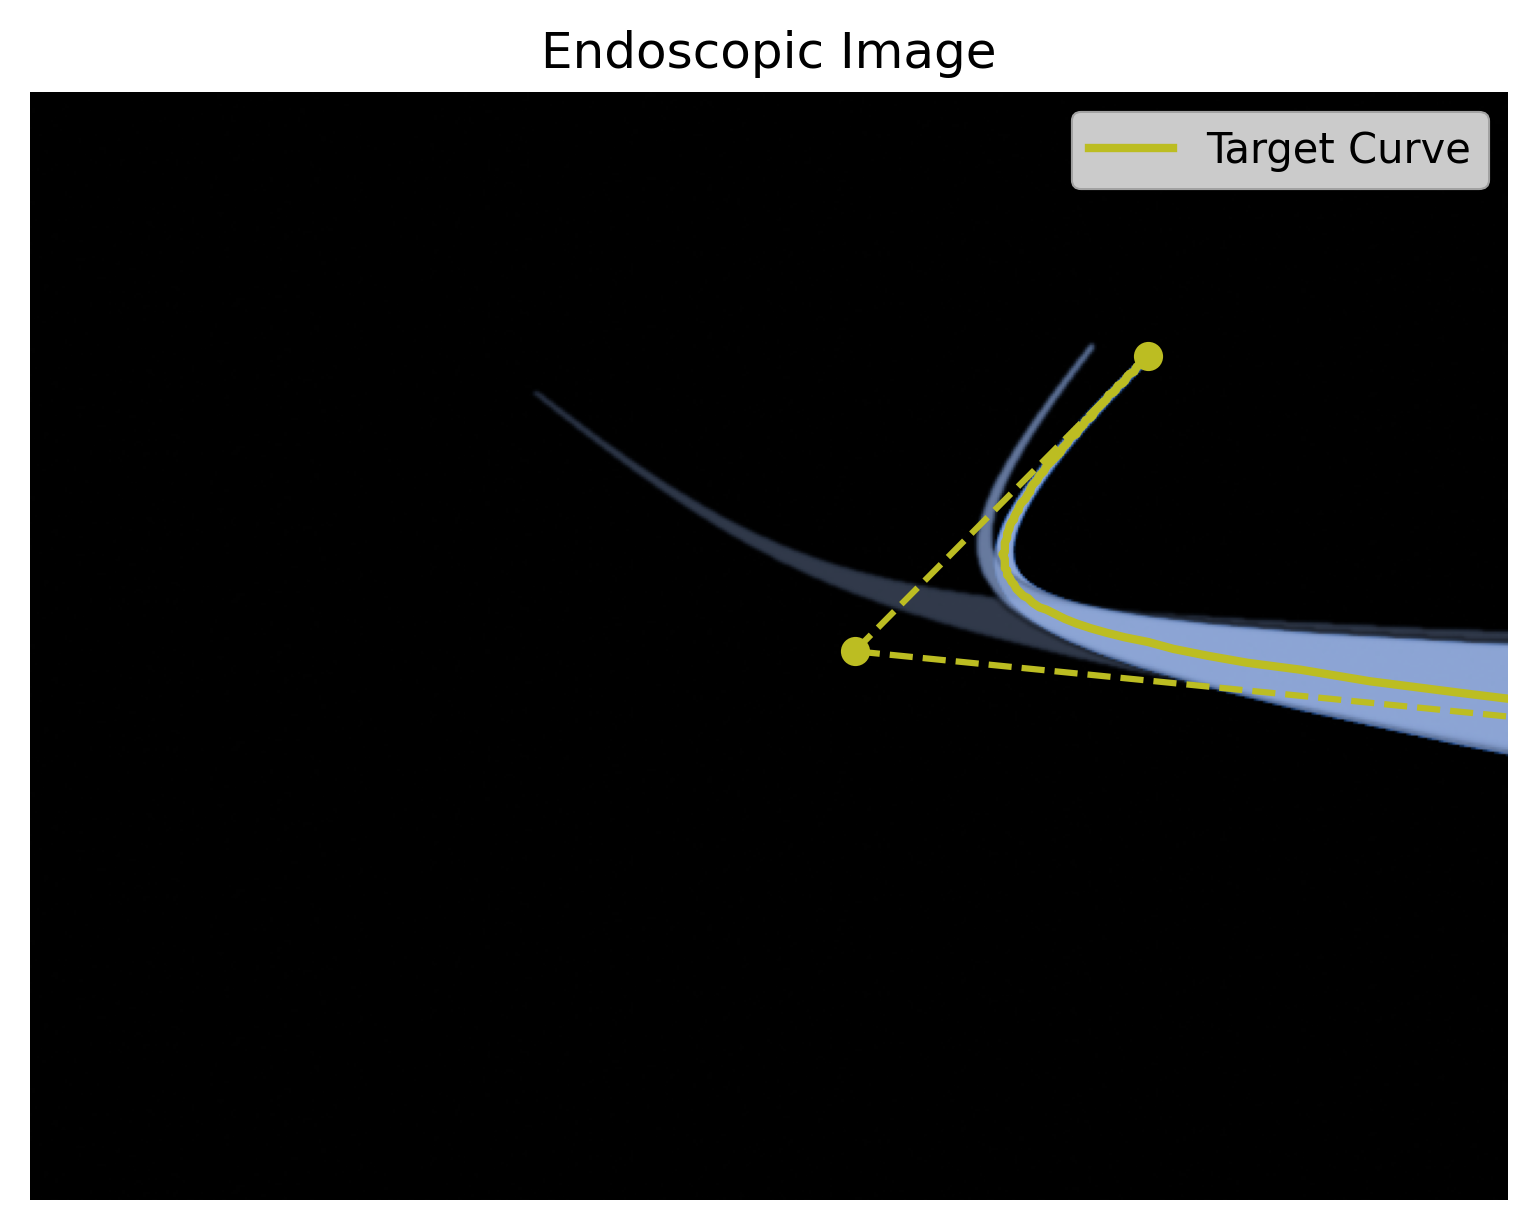

In [31]:
image_save_path = output_path
image = cv2.imread(image_save_path)
# Convert color channel: BGR -> RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

para_gt = read_gt_params(params_save_path)
p2_3d = para_gt[-3:]
p1_3d = para_gt[:3]
p0_3d = np.array([2e-2, 2e-3, 0.00001])

print(p2_3d)
print(p1_3d)

control_points = np.vstack([p0_3d, p1_3d, p2_3d])

bezier_3d = bezier_curve_3d(control_points)

print(bezier_3d.shape)

bezier_2d = np.zeros((bezier_3d.shape[0], 2))
for i in range(bezier_3d.shape[0]):
    bezier_2d[i] = convert_3d_to_2d(bezier_3d[i], camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
    
p2_2d = convert_3d_to_2d(p2_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
p1_2d = convert_3d_to_2d(p1_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
p0_2d = convert_3d_to_2d(p0_3d, camera_settings.extrinsics, camera_settings.a, camera_settings.b, camera_settings.center_x, camera_settings.center_y)
    
bezier_points = bezier_2d[1:, :]
# bezier_points = bezier_2d

plt.figure(dpi=300)
plt.imshow(image)

color_target = '#bcbd22'
# Plot the Bezier curve
plt.plot(bezier_points[:, 0], bezier_points[:, 1], color=color_target, linewidth=2, label='Target Curve')

# Plot control points
plt.scatter([p0_2d[0], p1_2d[0], p2_2d[0]], [p0_2d[1], p1_2d[1], p2_2d[1]], color=color_target)
# Connect control points with dashed lines (P0 to P1, P1 to P2)
plt.plot([p0_2d[0], p1_2d[0]], [p0_2d[1], p1_2d[1]], linestyle='--', color=color_target)
plt.plot([p1_2d[0], p2_2d[0]], [p1_2d[1], p2_2d[1]], linestyle='--', color=color_target)

# Set the axis limits to match the image size
plt.xlim(0, 640)  # X axis limit for image width
plt.ylim(480, 0)  # Y axis limit for image height, inverted to match image coordinates

plt.title("Endoscopic Image")
plt.axis('off')  
plt.legend()
plt.show()